# Map `spatialrs` outputs back to `AnnData`

This notebook loads the CSV outputs from the full `spatialrs` pipeline and attaches them back onto an `.h5ad` object.

It uses the natural AnnData slots for each output type:
- `obs`: hard niche labels and small per-cell summaries
- `obsm`: dense per-cell matrices like NMF W, aggregated embeddings, niche probabilities, and composition
- `varm`: gene loadings from NMF H
- `obsp`: sparse graph matrices from `radius` and `knn`
- `uns`: long-form tables and model summaries that do not fit a single cell or gene axis


In [34]:
from pathlib import Path
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import sparse

pd.options.display.max_columns = 200
pd.options.display.max_rows = 200
sns.set_theme(style="whitegrid")


## Configure paths

Point `H5AD_PATH` at the source dataset and `PROJECT_DIR` at the folder where the end-to-end bash script wrote its CSV outputs.


In [58]:
H5AD_PATH = Path("/Users/christoffer/work/karolinska/development/baloMS/data/baloMS_indep_clust_balo_MANA_balo.h5ad")
PROJECT_DIR = Path("../projects/balo-take2")
OUTPUT_PREFIX = "spatialrs"

SAVE_H5AD_PATH = PROJECT_DIR / "mapped_outputs.h5ad"  # set to None to skip writing
MARKER_LAYER = None  # set to a layer name like "counts" to inspect marker expression from that layer
MARKER_TOP_PER_NICHE = 5
MARKER_Q_MAX = 0.05
MARKER_LOG2FC_MIN = 0.5
NMF_TOP_COMPONENTS_PER_NICHE = 5
NMF_TOP_GENES_PER_COMPONENT = 5
NMF_ENRICH_EPS = 1e-9
NMF_COMPONENT_PLOTS_MAX = 6
NMF_TOP_LOADINGS_TO_PLOT = 10
NMF_COMPONENT_IDS = None  # optional explicit list, e.g. ["component_0", "component_3"]
NMF_SPATIAL_COMPONENTS = None  # optional explicit list, e.g. ["component_0", "component_3"]
NMF_SPATIAL_N_TOP = 4
NMF_SPATIAL_SAMPLE = None  # optional sample/group name for per-sample spatial maps
NMF_SPATIAL_POINT_SIZE = 2.0
NMF_SPATIAL_CMAP = "viridis"
NMF_SPATIAL_QMIN = 0.01
NMF_SPATIAL_QMAX = 0.99
NMF_OBS_COMPONENTS = None  # optional explicit list, e.g. ["component_0", "component_3"]
NMF_OBS_TOP_N = 4
NMF_OBS_PREFIX = "spatialrs_nmf_score"
NMF_OBS_PLOT_GROUPBY = "sample_id"
NMF_OBS_PLOT_SPOT_SIZE = 1
NMF_OBS_PLOT_COLS = 2
NMF_OBS_PLOT_HEIGHT = 5
NMF_OBS_PLOT_BACKGROUND = "black"
NMF_OBS_PLOT_DPI = 120

FILES = {
    "radius_edges": PROJECT_DIR / "radius_edges.csv",
    "knn_edges": PROJECT_DIR / "knn_edges.csv",
    "interactions": PROJECT_DIR / "interactions.csv",
    "interaction_stats": PROJECT_DIR / "interaction_stats.csv",
    "composition": PROJECT_DIR / "composition.csv",
    "nmf_w": PROJECT_DIR / "nmf_w.csv",
    "nmf_h": PROJECT_DIR / "nmf_h.csv",
    "agg": PROJECT_DIR / "agg.csv",
    "niches": PROJECT_DIR / "niches.csv",
    "niche_probs": PROJECT_DIR / "niche_probs.csv",
    "model_stats": PROJECT_DIR / "model_stats.csv",
    "morans_nmf": PROJECT_DIR / "morans_nmf.csv",
    "morans_embedding": PROJECT_DIR / "morans_embedding.csv",
    "markers": PROJECT_DIR / "markers.csv",
}

H5AD_PATH, PROJECT_DIR


(PosixPath('/Users/christoffer/work/karolinska/development/baloMS/data/baloMS_indep_clust_balo_MANA_balo.h5ad'),
 PosixPath('../projects/balo-take2'))

In [54]:
def read_csv_if_exists(path: Path, required: bool = False):
    if path is None:
        return None
    if not path.exists():
        if required:
            raise FileNotFoundError(path)
        print(f"skip: {path} not found")
        return None
    df = pd.read_csv(path)
    print(f"loaded {path.name:>22}  rows={len(df):>10,}  cols={list(df.columns)}")
    return df


def align_long_matrix(df, axis_names, index_col, column_col, value_col, fill_value=None):
    if df is None:
        return None
    wide = df.pivot_table(
        index=index_col,
        columns=column_col,
        values=value_col,
        aggfunc="first",
    )
    wide = wide.reindex(axis_names)
    if fill_value is not None:
        wide = wide.fillna(fill_value)
    return wide


def store_obsm_frame(adata, key, frame):
    if frame is None:
        return
    adata.obsm[key] = frame.to_numpy()
    adata.uns[f"{key}_columns"] = frame.columns.astype(str).tolist()


def store_varm_frame(adata, key, frame):
    if frame is None:
        return
    adata.varm[key] = frame.to_numpy()
    adata.uns[f"{key}_columns"] = frame.columns.astype(str).tolist()


def edge_csv_to_sparse(df, obs_names, value_col="distance"):
    if df is None:
        return None
    lookup = pd.Series(np.arange(len(obs_names), dtype=np.int64), index=obs_names)
    row_ids = lookup.reindex(df["cell_i"]).to_numpy()
    col_ids = lookup.reindex(df["cell_j"]).to_numpy()
    mask = (~pd.isna(row_ids)) & (~pd.isna(col_ids))
    n_missing = int((~mask).sum())
    if n_missing:
        warnings.warn(f"{n_missing} graph edges reference cells missing from adata.obs_names")
    row_ids = row_ids[mask].astype(np.int64)
    col_ids = col_ids[mask].astype(np.int64)
    values = df.loc[mask, value_col].to_numpy(dtype=float)
    matrix = sparse.coo_matrix((values, (row_ids, col_ids)), shape=(len(obs_names), len(obs_names))).tocsr()
    matrix.sum_duplicates()
    return matrix


def add_obs_column(adata, key, series, as_category=False):
    if series is None:
        return
    values = series.reindex(adata.obs_names)
    adata.obs[key] = values.astype("category") if as_category else values


def shannon_entropy(prob_matrix):
    p = np.clip(prob_matrix, 1e-12, 1.0)
    return -(p * np.log(p)).sum(axis=1)


def select_top_markers(markers, top_n=5, q_max=0.05, log2fc_min=0.5):
    if markers is None or markers.empty:
        return pd.DataFrame()
    filtered = markers.loc[
        (markers["q_value_bh"] <= q_max) & (markers["log2fc"] >= log2fc_min)
    ].copy()
    if filtered.empty:
        filtered = markers.copy()
    return (
        filtered.sort_values(["niche", "q_value_bh", "log2fc"], ascending=[True, True, False])
        .groupby("niche", group_keys=False)
        .head(top_n)
    )


def get_expression_frame(adata, genes, layer=None):
    genes = [g for g in pd.Index(genes).astype(str).unique() if g in adata.var_names]
    if not genes:
        return pd.DataFrame(index=adata.obs_names)
    matrix = adata[:, genes].layers[layer] if layer else adata[:, genes].X
    if sparse.issparse(matrix):
        matrix = matrix.toarray()
    return pd.DataFrame(np.asarray(matrix), index=adata.obs_names, columns=genes)


def map_nmf_components_to_obs(adata, output_prefix="spatialrs", components=None, top_n=4, obs_prefix="spatialrs_nmf_score"):
    nmf_key = f"{output_prefix}_nmf_w"
    nmf_cols_key = f"{output_prefix}_nmf_w_columns"

    if nmf_key not in adata.obsm:
        raise KeyError(f"{nmf_key} not found in adata.obsm")

    nmf_w = adata.obsm[nmf_key]
    if sparse.issparse(nmf_w):
        nmf_w = nmf_w.toarray()
    nmf_w = np.asarray(nmf_w, dtype=float)

    nmf_cols = adata.uns.get(nmf_cols_key)
    if not isinstance(nmf_cols, (list, tuple, np.ndarray)) or len(nmf_cols) != nmf_w.shape[1]:
        nmf_cols = [f"component_{i}" for i in range(nmf_w.shape[1])]
    else:
        nmf_cols = [str(c) for c in nmf_cols]

    nmf_df = pd.DataFrame(nmf_w, index=adata.obs_names, columns=nmf_cols)

    if components is None:
        top_components = adata.uns.get(f"{output_prefix}_nmf_top_components")
        if isinstance(top_components, pd.DataFrame) and not top_components.empty and "component" in top_components.columns:
            components = top_components["component"].astype(str).drop_duplicates().head(top_n).tolist()
        else:
            components = nmf_cols[:top_n]
    else:
        components = [str(c) for c in components]

    mapped_cols = []
    for component in components:
        if component not in nmf_df.columns:
            continue
        obs_col = f"{obs_prefix}_{component}"
        adata.obs[obs_col] = nmf_df[component].to_numpy()
        mapped_cols.append(obs_col)

    return mapped_cols



## Load the `.h5ad` and all available CSV outputs

The notebook tolerates missing optional files, so you can rerun it even if only part of the pipeline was generated.


In [37]:
adata = ad.read_h5ad(H5AD_PATH)
adata.obs_names = adata.obs_names.astype(str)
adata.var_names = adata.var_names.astype(str)

outputs = {name: read_csv_if_exists(path) for name, path in FILES.items()}

print()
print(adata)
print(f"obs_names={adata.n_obs:,}  var_names={adata.n_vars:,}")


loaded       radius_edges.csv  rows=18,907,610  cols=['cell_i', 'cell_j', 'distance', 'group']
loaded          knn_edges.csv  rows=   717,210  cols=['cell_i', 'cell_j', 'distance', 'group']
loaded       interactions.csv  rows=       240  cols=['group', 'cell_type_a', 'cell_type_b', 'count']
loaded  interaction_stats.csv  rows=       240  cols=['group', 'cell_type_a', 'cell_type_b', 'observed', 'expected_mean', 'expected_std', 'z_score', 'p_value']
loaded        composition.csv  rows=   825,257  cols=['cell_i', 'cell_type', 'fraction', 'group']
loaded              nmf_w.csv  rows= 1,434,420  cols=['cell_i', 'component', 'weight', 'group']
loaded              nmf_h.csv  rows=   102,020  cols=['gene', 'component', 'loading', 'group']
loaded                agg.csv  rows= 1,434,420  cols=['cell_i', 'dim', 'value', 'group']
loaded             niches.csv  rows=    71,721  cols=['cell_i', 'niche', 'group']
loaded        niche_probs.csv  rows=   860,652  cols=['cell_i', 'component', 'probabilit

## Attach per-cell and per-gene outputs

This section maps the outputs that naturally align to cells or genes.


In [38]:
# Hard niche assignments -> obs
if outputs["niches"] is not None:
    niche_map = (
        outputs["niches"]
        .drop_duplicates(subset=["cell_i"])
        .set_index("cell_i")["niche"]
        .astype("Int64")
    )
    add_obs_column(adata, f"{OUTPUT_PREFIX}_niche", niche_map, as_category=True)
    print("mapped obs column:", f"{OUTPUT_PREFIX}_niche")

# Niche probabilities -> obsm + convenience obs summaries
niche_probs = align_long_matrix(outputs["niche_probs"], adata.obs_names, "cell_i", "component", "probability", fill_value=0.0)
if niche_probs is not None:
    niche_probs.columns = [f"niche_{int(c)}" for c in niche_probs.columns]
    probs_key = f"{OUTPUT_PREFIX}_niche_probs"
    store_obsm_frame(adata, probs_key, niche_probs)
    adata.obs[f"{OUTPUT_PREFIX}_niche_confidence"] = niche_probs.max(axis=1).to_numpy()
    adata.obs[f"{OUTPUT_PREFIX}_niche_entropy"] = shannon_entropy(niche_probs.to_numpy())
    print("mapped obsm key:", probs_key)

# NMF W -> obsm
nmf_w = align_long_matrix(outputs["nmf_w"], adata.obs_names, "cell_i", "component", "weight", fill_value=0.0)
if nmf_w is not None:
    nmf_w.columns = [f"component_{int(c)}" for c in nmf_w.columns]
    w_key = f"{OUTPUT_PREFIX}_nmf_w"
    store_obsm_frame(adata, w_key, nmf_w)
    print("mapped obsm key:", w_key)

# Aggregated embedding -> obsm
agg = align_long_matrix(outputs["agg"], adata.obs_names, "cell_i", "dim", "value", fill_value=0.0)
if agg is not None:
    agg.columns = [f"dim_{int(c)}" for c in agg.columns]
    agg_key = f"{OUTPUT_PREFIX}_agg"
    store_obsm_frame(adata, agg_key, agg)
    print("mapped obsm key:", agg_key)

# Composition -> obsm
composition = align_long_matrix(outputs["composition"], adata.obs_names, "cell_i", "cell_type", "fraction", fill_value=0.0)
if composition is not None:
    composition.columns = [str(c) for c in composition.columns]
    comp_key = f"{OUTPUT_PREFIX}_composition"
    store_obsm_frame(adata, comp_key, composition)
    print("mapped obsm key:", comp_key)

# NMF H -> varm
nmf_h = align_long_matrix(outputs["nmf_h"], adata.var_names, "gene", "component", "loading", fill_value=0.0)
if nmf_h is not None:
    nmf_h.columns = [f"component_{int(c)}" for c in nmf_h.columns]
    h_key = f"{OUTPUT_PREFIX}_nmf_h"
    store_varm_frame(adata, h_key, nmf_h)
    print("mapped varm key:", h_key)


mapped obs column: spatialrs_niche
mapped obsm key: spatialrs_niche_probs
mapped obsm key: spatialrs_nmf_w
mapped obsm key: spatialrs_agg
mapped obsm key: spatialrs_composition
mapped varm key: spatialrs_nmf_h


## Attach graph outputs and long-form summaries

Edge lists become sparse matrices in `obsp`. Outputs that are sample-level, feature-level, or pooled summaries stay in `uns`.


In [39]:
radius_graph = edge_csv_to_sparse(outputs["radius_edges"], adata.obs_names)
if radius_graph is not None:
    key = f"{OUTPUT_PREFIX}_radius_distances"
    adata.obsp[key] = radius_graph
    print("mapped obsp key:", key, "nnz=", radius_graph.nnz)

knn_graph = edge_csv_to_sparse(outputs["knn_edges"], adata.obs_names)
if knn_graph is not None:
    key = f"{OUTPUT_PREFIX}_knn_distances"
    adata.obsp[key] = knn_graph
    print("mapped obsp key:", key, "nnz=", knn_graph.nnz)

for name in [
    "interactions",
    "interaction_stats",
    "composition",
    "model_stats",
    "morans_nmf",
    "morans_embedding",
    "markers",
]:
    df = outputs[name]
    if df is not None:
        adata.uns[f"{OUTPUT_PREFIX}_{name}"] = df

adata.uns[f"{OUTPUT_PREFIX}_source_files"] = {k: str(v) for k, v in FILES.items()}


mapped obsp key: spatialrs_radius_distances nnz= 18907610
mapped obsp key: spatialrs_knn_distances nnz= 717210


## Sanity checks

These checks make it easy to confirm where each output landed before writing a new `.h5ad`.


In [40]:
mapped_obs = [c for c in adata.obs.columns if c.startswith(OUTPUT_PREFIX)]
mapped_uns = [k for k in adata.uns.keys() if k.startswith(OUTPUT_PREFIX)]

print("obs columns")
print(mapped_obs)
print()
print("obsm keys")
print(list(adata.obsm.keys()))
print()
print("varm keys")
print(list(adata.varm.keys()))
print()
print("obsp keys")
print(list(adata.obsp.keys()))
print()
print("uns keys")
print(mapped_uns)
print()

preview_cols = [c for c in [f"{OUTPUT_PREFIX}_niche", f"{OUTPUT_PREFIX}_niche_confidence", f"{OUTPUT_PREFIX}_niche_entropy"] if c in adata.obs.columns]
if preview_cols:
    display(adata.obs[preview_cols].head())


obs columns
['spatialrs_niche', 'spatialrs_niche_confidence', 'spatialrs_niche_entropy']

obsm keys
['X_mana_gauss', 'X_pca', 'X_scVI', 'X_umap', 'spatial', 'spatialrs_niche_probs', 'spatialrs_nmf_w', 'spatialrs_agg', 'spatialrs_composition']

varm keys
['PCs', 'spatialrs_nmf_h']

obsp keys
['connectivities', 'distances', 'spatial_connectivities', 'spatial_distances', 'spatialrs_radius_distances', 'spatialrs_knn_distances']

uns keys
['spatialrs_niche_probs_columns', 'spatialrs_nmf_w_columns', 'spatialrs_agg_columns', 'spatialrs_composition_columns', 'spatialrs_nmf_h_columns', 'spatialrs_interactions', 'spatialrs_interaction_stats', 'spatialrs_composition', 'spatialrs_model_stats', 'spatialrs_morans_nmf', 'spatialrs_morans_embedding', 'spatialrs_markers', 'spatialrs_source_files']



,spatialrs_niche,spatialrs_niche_confidence,spatialrs_niche_entropy
cell_id,,,
aaaegnpp-1,1,1.000000,9.037770e-09
aaaekeog-1,1,1.000000,3.040762e-10
aaagdcml-1,3,1.000000,3.042764e-10
aaaghaod-1,1,0.999735,2.452184e-03
aaagmlef-1,3,1.000000,1.044441e-07


## Analysis

The next cells interrogate the outputs that were mapped back into `adata`, with a focus on niche abundance, NMF component enrichment, assignment certainty, marker interpretation, and spatial structure.


,n_cells,fraction
spatialrs_niche,,
0,4366,0.060875
1,3375,0.047057
2,7625,0.106315
3,5330,0.074316
4,4408,0.06146
5,5433,0.075752
6,6274,0.087478
7,10573,0.147418
8,6651,0.092734


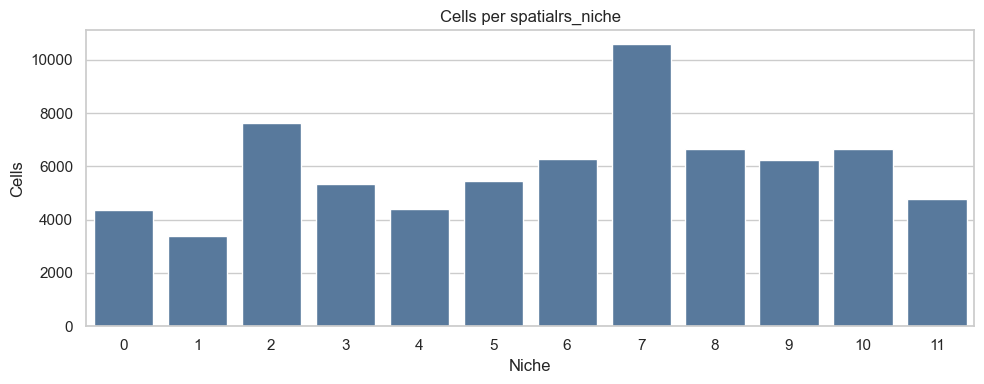

,k,log_likelihood,bic,aic,n_iter,covariance_type,group
0,12,1.061668e+06,-2.117847e+06,-2.122355e+06,113,diagonal,all


In [41]:
niche_col = f"{OUTPUT_PREFIX}_niche"
confidence_col = f"{OUTPUT_PREFIX}_niche_confidence"
entropy_col = f"{OUTPUT_PREFIX}_niche_entropy"

if niche_col in adata.obs:
    niche_counts = (
        adata.obs[niche_col]
        .astype("Int64")
        .value_counts(dropna=False)
        .sort_index()
        .rename("n_cells")
        .to_frame()
    )
    niche_counts["fraction"] = niche_counts["n_cells"] / niche_counts["n_cells"].sum()
    display(niche_counts)

    counts_plot = niche_counts.reset_index().rename(columns={"index": "niche"})
    counts_plot["spatialrs_niche"] = counts_plot["spatialrs_niche"].astype(str)
    plt.figure(figsize=(10, 4))
    sns.barplot(data=counts_plot, x="spatialrs_niche", y="n_cells", color="#4C78A8")
    plt.title("Cells per spatialrs_niche")
    plt.xlabel("Niche")
    plt.ylabel("Cells")
    plt.tight_layout()
    plt.show()
else:
    print(f"{niche_col} not found in adata.obs")

model_stats = adata.uns.get(f"{OUTPUT_PREFIX}_model_stats")
if isinstance(model_stats, pd.DataFrame) and not model_stats.empty:
    display(model_stats.sort_values(["bic", "aic"]).head(10))


spatialrs_niche,0,1,10,11,2,3,4,5,6,7,8,9
group,,,,,,,,,,,,
Balo-1,0.140826,0.071334,0.000000,0.141763,0.062062,0.008691,0.077957,0.038768,0.103673,0.286725,0.000355,0.067845
Balo-2,0.000172,0.028625,0.163192,0.009591,0.139914,0.124141,0.048935,0.103831,0.075182,0.041650,0.162873,0.101894


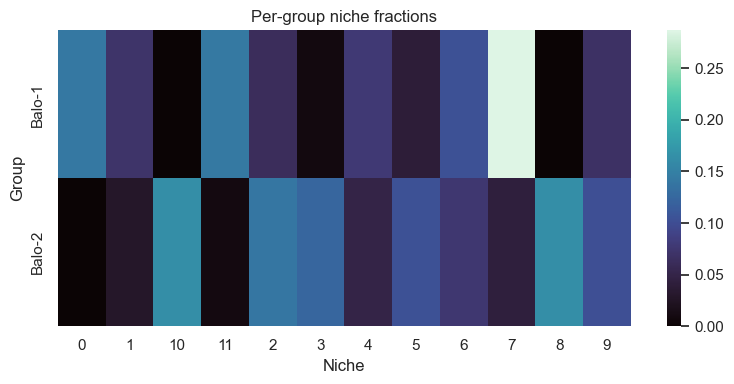

,n_cells,median_confidence,mean_confidence,median_entropy,mean_entropy
spatialrs_niche,,,,,
0,4366,0.999879,0.957789,1.214600e-03,0.101346
1,3375,1.000000,0.997981,3.040194e-10,0.005287
2,7625,0.999983,0.968384,2.046692e-04,0.077375
3,5330,1.000000,0.978236,4.673271e-06,0.051866
4,4408,1.000000,0.980163,1.889323e-07,0.049523
5,5433,1.000000,0.988122,1.778157e-09,0.029063
6,6274,0.999999,0.957564,1.568660e-05,0.097810
7,10573,0.999905,0.967928,9.915174e-04,0.081157
8,6651,0.999996,0.984052,5.390957e-05,0.038562


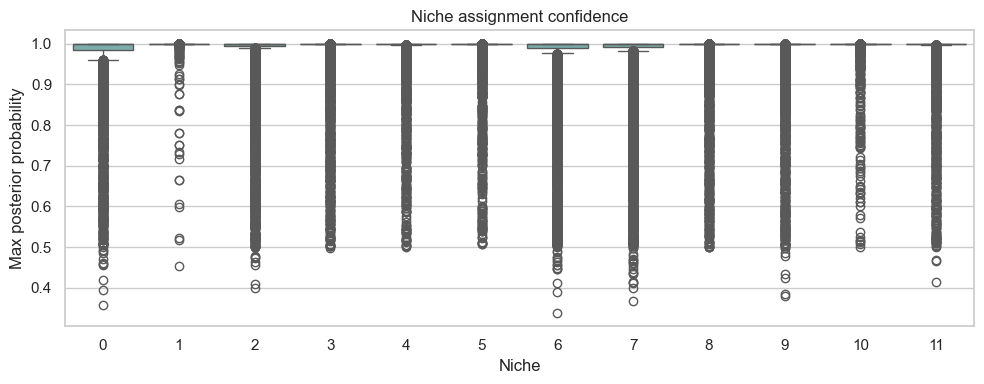

In [42]:
group_series = None
if outputs["niches"] is not None and "group" in outputs["niches"].columns:
    group_series = (
        outputs["niches"]
        .drop_duplicates(subset=["cell_i"])
        .set_index("cell_i")["group"]
        .reindex(adata.obs_names)
        .fillna("missing")
        .astype(str)
    )

if group_series is not None and niche_col in adata.obs:
    abundance = pd.crosstab(group_series, adata.obs[niche_col].astype(str), normalize="index")
    display(abundance)

    plt.figure(figsize=(max(8, abundance.shape[1] * 0.6), max(4, abundance.shape[0] * 0.5)))
    sns.heatmap(abundance, cmap="mako", vmin=0.0, vmax=float(abundance.to_numpy().max()))
    plt.title("Per-group niche fractions")
    plt.xlabel("Niche")
    plt.ylabel("Group")
    plt.tight_layout()
    plt.show()
else:
    print("No group information available for niche-abundance heatmap")

if confidence_col in adata.obs and entropy_col in adata.obs and niche_col in adata.obs:
    assignment_quality = (
        adata.obs[[niche_col, confidence_col, entropy_col]]
        .dropna()
        .groupby(niche_col, observed=False)
        .agg(
            n_cells=(confidence_col, "size"),
            median_confidence=(confidence_col, "median"),
            mean_confidence=(confidence_col, "mean"),
            median_entropy=(entropy_col, "median"),
            mean_entropy=(entropy_col, "mean"),
        )
        .sort_index()
    )
    display(assignment_quality)

    plt.figure(figsize=(10, 4))
    sns.boxplot(
        data=adata.obs[[niche_col, confidence_col]].dropna(),
        x=niche_col,
        y=confidence_col,
        color="#72B7B2",
    )
    plt.title("Niche assignment confidence")
    plt.xlabel("Niche")
    plt.ylabel("Max posterior probability")
    plt.tight_layout()
    plt.show()


,niche,gene,mean_niche,mean_rest,log2fc,z_score,p_value,q_value_bh
511,0,CALM3,5.416399,2.345973,1.207148,34.800872,2.716008e-265,4.618118e-262
4223,0,SNAP25,6.080165,2.818054,1.109411,33.963927,8.721661e-253,1.112230e-249
4227,0,SNCB,4.446404,1.956351,1.184474,33.848530,4.376760e-251,3.720976e-248
4784,0,TSPAN7,2.607192,1.298552,1.005593,33.853059,3.754252e-251,3.720976e-248
503,0,CADM3,2.903344,1.157791,1.326341,32.790465,9.204709e-236,6.707603e-233
10014,1,VIM,1.677926,0.785547,1.094909,27.460087,5.894493e-166,4.625816e-164
9358,1,SOCS3,0.452148,0.094534,2.257895,16.156212,1.084861e-58,2.080404e-57
8183,1,NR4A1,0.645630,0.252363,1.355207,14.469078,1.987553e-47,3.053767e-46
5313,1,ANXA2,0.305185,0.069997,2.124324,12.823565,1.253558e-37,1.487069e-36
9921,1,TXNIP,0.412741,0.207810,0.989969,11.158696,6.663321e-29,6.146402e-28


,n_markers,median_log2fc,best_q
niche,,,
0,5,1.184474,4.618118e-262
1,5,1.355207,4.625816e-164
2,5,0.769160,3.566946e-78
3,5,1.001578,0.000000e+00
4,5,0.962084,4.919879e-157
5,5,1.116363,0.000000e+00
6,5,1.236504,1.811464e-312
7,5,1.761531,0.000000e+00
8,5,1.353902,0.000000e+00


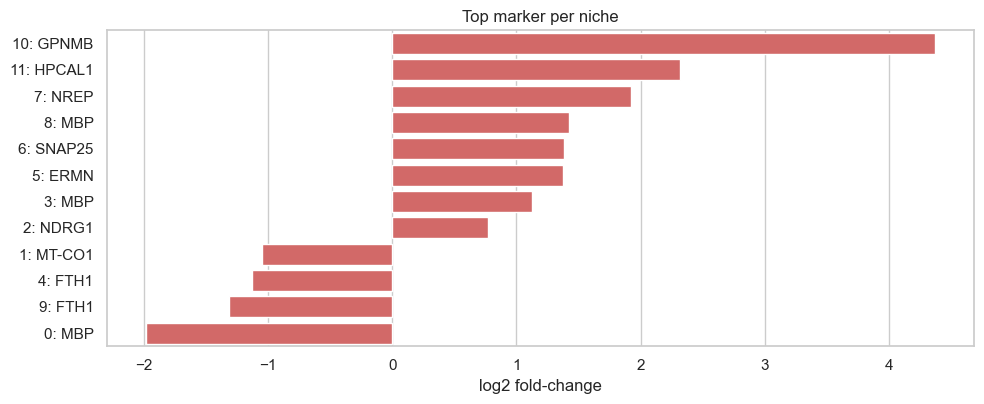

,gene,component,loading,group
84460,SNAP25,0,1.882910,all
77900,RTN1,0,1.247914,all
88700,SYP,0,1.243049,all
77920,RTN4,0,0.705983,all
82020,SLC17A7,0,0.670635,all
68920,PNMA2,0,0.649519,all
71260,PRNP,0,0.637527,all
10220,CALM3,0,0.630562,all
36560,GPM6A,0,0.620567,all
87960,STMN2,0,0.596196,all


In [43]:
marker_panel = pd.DataFrame()
markers = adata.uns.get(f"{OUTPUT_PREFIX}_markers")
if isinstance(markers, pd.DataFrame) and not markers.empty:
    marker_panel = select_top_markers(
        markers,
        top_n=MARKER_TOP_PER_NICHE,
        q_max=MARKER_Q_MAX,
        log2fc_min=MARKER_LOG2FC_MIN,
    )
    display(marker_panel)

    marker_summary = (
        marker_panel.groupby("niche", observed=True)
        .agg(
            n_markers=("gene", "size"),
            median_log2fc=("log2fc", "median"),
            best_q=("q_value_bh", "min"),
        )
        .sort_index()
    )
    display(marker_summary)

    best_marker = (
        markers.sort_values(["q_value_bh", "log2fc"], ascending=[True, False])
        .groupby("niche", group_keys=False)
        .head(1)
        .copy()
    )
    best_marker["label"] = best_marker["niche"].astype(str) + ": " + best_marker["gene"].astype(str)
    plt.figure(figsize=(10, max(4, len(best_marker) * 0.35)))
    sns.barplot(data=best_marker.sort_values("log2fc", ascending=False), x="log2fc", y="label", color="#E45756")
    plt.title("Top marker per niche")
    plt.xlabel("log2 fold-change")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()
else:
    print("No markers table available")

if outputs["nmf_h"] is not None:
    top_loadings = (
        outputs["nmf_h"]
        .sort_values(["component", "loading"], ascending=[True, False])
        .groupby("component", group_keys=False)
        .head(10)
    )
    display(top_loadings)


gene,ANXA2,APOC1,AQP4,CADM3,CALM3,CNP,CNTNAP2,CRYAB,CXCR4,ERMN,FGFR3,GFAP,GJA1,GJB6,GPM6A,GPNMB,HPCAL1,MAP2K1,MBP,MOG,NAP1L5,NDRG1,NR4A1,NREP,NRN1,NTRK2,S100B,SERPINA3,SLC17A7,SLC1A2,SLC1A3,SLCO1C1,SNAP25,SNCB,SOCS3,SOX9,SPP1,STMN2,THY1,TSPAN7,TUBB4A,TXNIP,VIM
niche,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.000000,0.000000,0.000000,1.326341,1.207148,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.109411,1.184474,0.000000,0.000000,0.000000,0.000000,0.000000,1.005593,0.000000,0.000000,0.000000
1,2.124324,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.355207,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.257895,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.989969,1.094909
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.104271,0.000000,0.000000,0.000000,0.76916,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.703957,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.907591,0.000000,0.601278,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,1.070750,0.000000,0.917333,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.126063,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.001578,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.871913,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.962084,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.992341,0.878592,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.777675,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.509392,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,1.223660,0.000000,0.931448,0.000000,1.373012,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.116363,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.006279,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,1.231274,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.470639,0.000000,0.000000,0.000000,1.382194,1.236504,0.000000,0.000000,0.000000,0.000000,0.000000,1.196976,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.654872,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.609666,0.00000,0.000000,1.923178,1.761531,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.907328,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,1.240737,0.000000,0.000000,0.000000,1.267599,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.426633,1.388599,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.353902,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


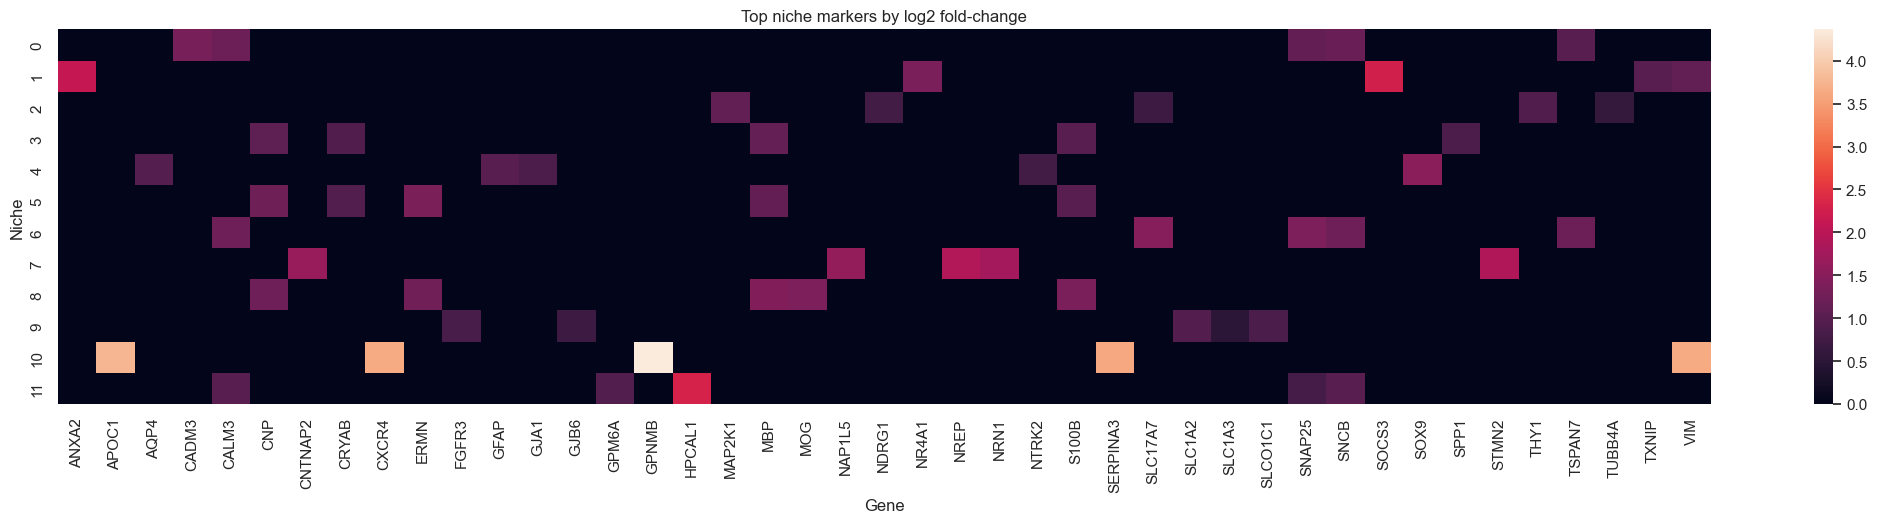

,CALM3,SNAP25,SNCB,TSPAN7,CADM3,VIM,SOCS3,NR4A1,ANXA2,TXNIP,NDRG1,MAP2K1,TUBB4A,THY1,SLC17A7,MBP,S100B,SPP1,CNP,CRYAB,AQP4,GFAP,GJA1,SOX9,NTRK2,ERMN,NREP,STMN2,NRN1,CNTNAP2,NAP1L5,MOG,SLC1A2,FGFR3,SLC1A3,GJB6,SLCO1C1,GPNMB,APOC1,CXCR4,SERPINA3,HPCAL1,GPM6A
spatialrs_niche,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.377380,0.372204,0.307838,0.259317,0.219627,0.034034,0.002329,0.036618,0.002383,0.022425,0.057812,0.090155,0.120538,0.176052,0.214808,0.189311,0.144309,0.169920,0.142485,0.088273,0.097892,0.130344,0.107428,0.061075,0.173345,0.039202,0.070020,0.167222,0.113617,0.091750,0.106415,0.039954,0.380096,0.125547,0.211707,0.037071,0.022705,0.018540,0.015848,0.004981,0.000961,0.095533,0.278264
1,0.038083,0.005178,0.003511,0.013240,0.009298,0.507964,0.168642,0.237955,0.120142,0.217652,0.096159,0.022728,0.045489,0.006096,0.003020,0.361093,0.184353,0.199453,0.176117,0.162194,0.040457,0.254299,0.054252,0.017475,0.036797,0.062276,0.010592,0.004038,0.006976,0.006221,0.009801,0.069955,0.012834,0.015012,0.047144,0.026021,0.003203,0.036793,0.051623,0.071517,0.057950,0.020274,0.037882
2,0.245681,0.248068,0.176658,0.169004,0.118302,0.048949,0.008464,0.064951,0.005659,0.046898,0.160859,0.132426,0.180550,0.143109,0.162112,0.605397,0.357061,0.410316,0.437838,0.267274,0.134580,0.359677,0.088183,0.048617,0.115045,0.157641,0.047340,0.092646,0.059551,0.047573,0.056035,0.156312,0.188951,0.067107,0.120527,0.013772,0.015865,0.007014,0.037385,0.009924,0.007209,0.072108,0.202272
3,0.055670,0.022092,0.017403,0.034377,0.019560,0.115904,0.018568,0.054933,0.017428,0.084781,0.212543,0.031894,0.216427,0.021849,0.013493,1.132287,0.615264,0.683405,0.702893,0.508046,0.130070,0.777777,0.070462,0.039483,0.076097,0.272353,0.014122,0.007449,0.005952,0.017599,0.015655,0.284593,0.041831,0.023671,0.081979,0.001285,0.003783,0.060130,0.129254,0.042339,0.077426,0.037476,0.052018
4,0.104742,0.075208,0.083559,0.118248,0.068677,0.160887,0.063191,0.143114,0.012455,0.057528,0.033236,0.040310,0.053063,0.043138,0.041199,0.174214,0.362990,0.271254,0.130783,0.220025,0.308583,0.827549,0.212270,0.156396,0.285674,0.036509,0.034079,0.023073,0.016954,0.026870,0.038711,0.034784,0.368211,0.156492,0.204992,0.019661,0.030560,0.012566,0.022456,0.015895,0.034071,0.048847,0.203822
5,0.114107,0.082402,0.060465,0.073274,0.044412,0.061591,0.006347,0.040278,0.006710,0.078281,0.229526,0.056263,0.248328,0.059558,0.056699,1.091079,0.628148,0.604888,0.721285,0.488414,0.182201,0.746615,0.083307,0.050841,0.108448,0.287694,0.025916,0.035506,0.018208,0.027889,0.030954,0.277867,0.089705,0.038389,0.087019,0.004134,0.007552,0.009508,0.067787,0.012571,0.043413,0.062614,0.104560
6,0.326520,0.362034,0.263134,0.225976,0.165586,0.032690,0.006797,0.064775,0.003952,0.031290,0.123310,0.154151,0.168636,0.164476,0.217375,0.430634,0.235846,0.303912,0.318317,0.194623,0.101447,0.192373,0.093287,0.047229,0.125949,0.109597,0.078171,0.149082,0.097672,0.070292,0.088317,0.109305,0.247513,0.083728,0.143006,0.022102,0.015750,0.006711,0.021259,0.007287,0.004001,0.051447,0.242470
7,0.351713,0.408611,0.323064,0.254522,0.178510,0.025733,0.004575,0.044011,0.003156,0.024577,0.089588,0.108783,0.151626,0.143713,0.228551,0.342465,0.193179,0.231156,0.244059,0.146610,0.087432,0.129147,0.083470,0.049621,0.146009,0.077843,0.117831,0.187901,0.126426,0.103165,0.111333,0.078261,0.306291,0.093241,0.162946,0.031127,0.019038,0.009373,0.012205,0.006235,0.001605,0.030649,0.258973
8,0.043427,0.009735,0.006877,0.031627,0.016304,0.127557,0.011366,0.028648,0.018900,0.079144,0.204371,0.031891,0.226873,0.014874,0.005465,1.229754,0.680371,0.755061,0.733882,0.542466,0.104566,0.857313,0.054227,0.035354,0.066443,0.282474,0.013877,0.003291,0.003866,0.017378,0.014610,0.296486,0.034270,0.019543,0.072528,0.000848,0.004015,0.085760,0.183306,0.055533,0.108596,0.027983,0.041068


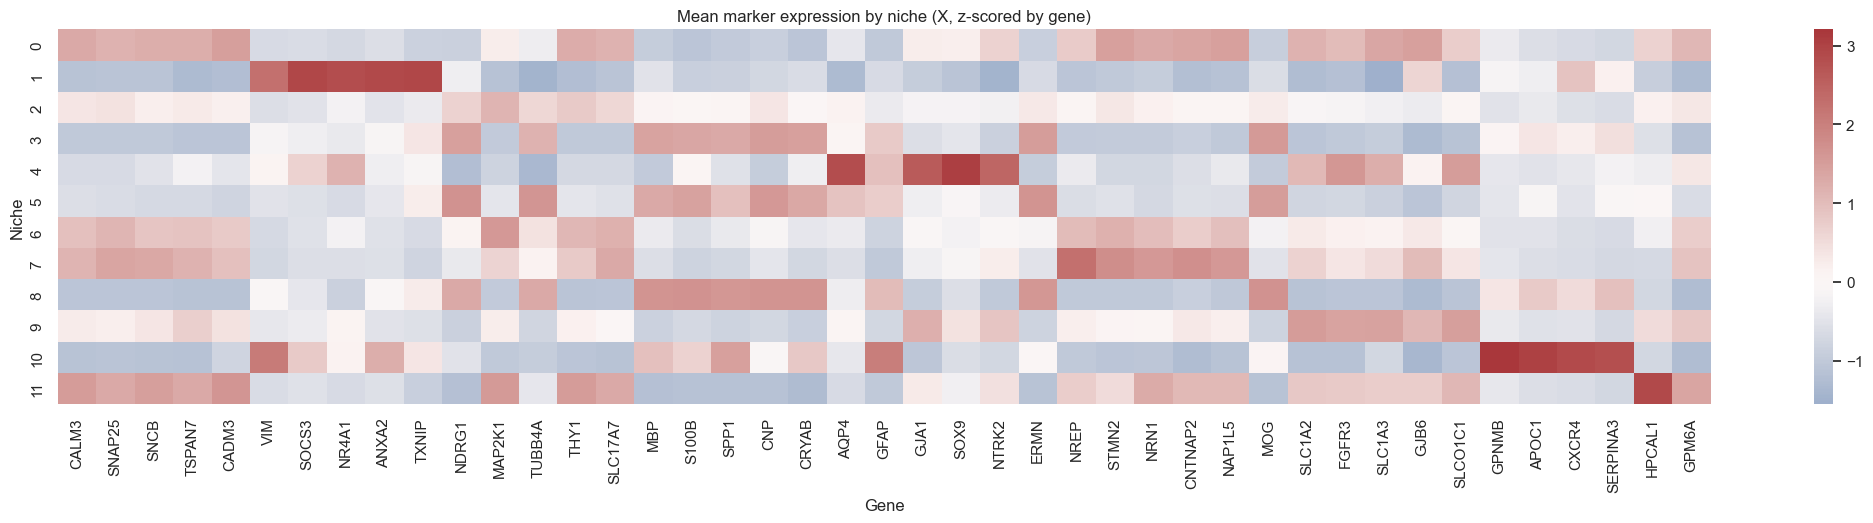

In [44]:
if not marker_panel.empty and niche_col in adata.obs:
    marker_heat = marker_panel.pivot_table(
        index="niche",
        columns="gene",
        values="log2fc",
        aggfunc="first",
        fill_value=0.0,
    ).sort_index()
    display(marker_heat)

    plt.figure(figsize=(max(8, marker_heat.shape[1] * 0.5), max(4, marker_heat.shape[0] * 0.45)))
    sns.heatmap(marker_heat, cmap="rocket", vmin=0)
    plt.title("Top niche markers by log2 fold-change")
    plt.xlabel("Gene")
    plt.ylabel("Niche")
    plt.tight_layout()
    plt.show()

    marker_genes = marker_panel["gene"].drop_duplicates().tolist()
    expr = get_expression_frame(adata, marker_genes, layer=MARKER_LAYER)
    niche_ids = adata.obs[niche_col].astype("Int64")
    valid = niche_ids.notna()
    if not expr.empty and valid.any():
        niche_means = expr.loc[valid].groupby(niche_ids.loc[valid].astype(int)).mean().sort_index()
        ordered_genes = [g for g in marker_panel.sort_values(["niche", "q_value_bh", "log2fc"], ascending=[True, True, False])["gene"].tolist() if g in niche_means.columns]
        ordered_genes = list(dict.fromkeys(ordered_genes))
        niche_means = niche_means.reindex(columns=ordered_genes)
        scaled = niche_means.copy()
        for col in scaled.columns:
            std = scaled[col].std(ddof=0)
            scaled[col] = 0.0 if std == 0 else (scaled[col] - scaled[col].mean()) / std
        display(niche_means)

        plt.figure(figsize=(max(8, scaled.shape[1] * 0.5), max(4, scaled.shape[0] * 0.45)))
        sns.heatmap(scaled, cmap="vlag", center=0)
        layer_label = MARKER_LAYER if MARKER_LAYER else "X"
        plt.title(f"Mean marker expression by niche ({layer_label}, z-scored by gene)")
        plt.xlabel("Gene")
        plt.ylabel("Niche")
        plt.tight_layout()
        plt.show()
    else:
        print("No overlapping marker genes found in adata.var_names for expression heatmap")
else:
    print("Marker panel unavailable for niche-level marker heatmaps")


### NMF component enrichment per niche

Estimate which NMF components are enriched in each niche by comparing mean component weights inside a niche versus all other cells.


,niche,component,n_cells_in_niche,n_cells_rest,mean_niche,mean_rest,delta,log2fc
12,0,component_12,4366,67355,0.981613,0.337587,0.644026,1.539896
1,0,component_1,4366,67355,1.191246,0.432254,0.758991,1.462519
4,0,component_4,4366,67355,1.087333,0.425026,0.662307,1.355171
16,0,component_16,4366,67355,1.065424,0.432808,0.632617,1.299630
2,0,component_2,4366,67355,0.818500,0.354800,0.463699,1.205974
30,1,component_10,3375,68346,0.528483,0.403095,0.125388,0.390737
34,1,component_14,3375,68346,0.225462,0.318432,-0.092970,-0.498101
27,1,component_7,3375,68346,0.662860,0.986585,-0.323724,-0.573738
25,1,component_5,3375,68346,0.370108,0.580344,-0.210236,-0.648960
31,1,component_11,3375,68346,0.328288,0.563266,-0.234978,-0.778855


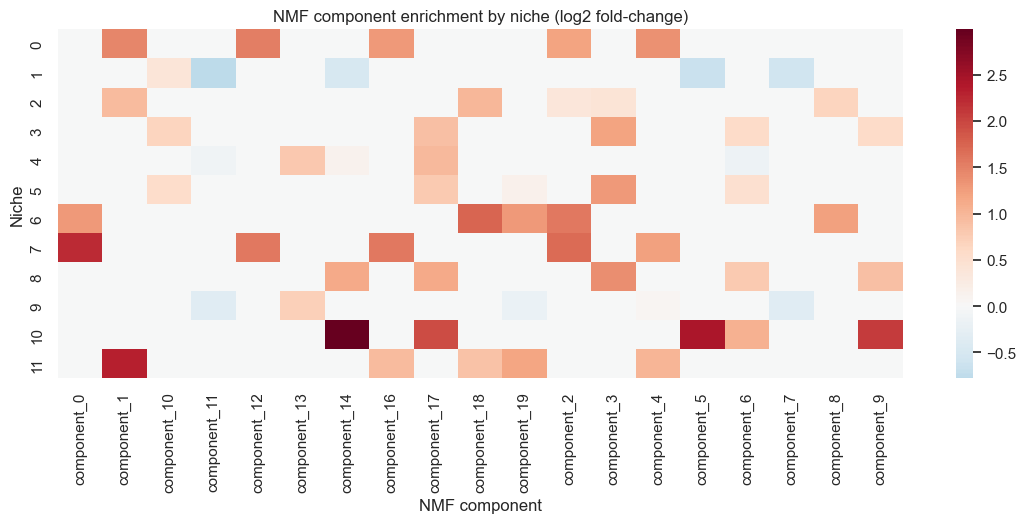

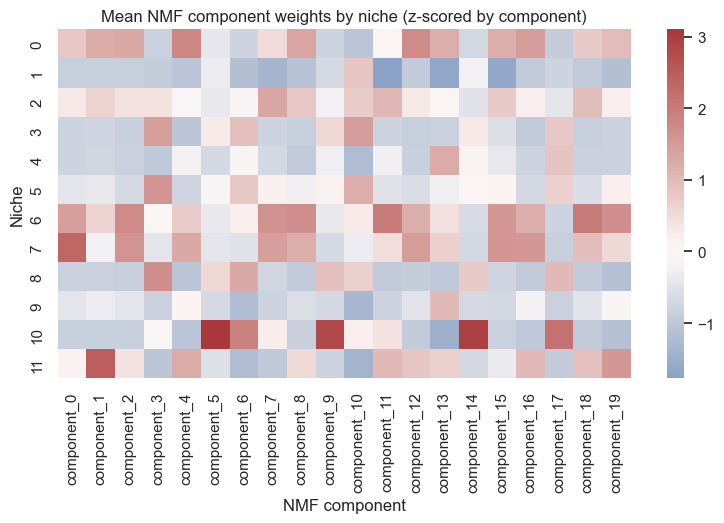

,niche,component,n_cells_in_niche,n_cells_rest,mean_niche,mean_rest,delta,log2fc,top_genes
12,0,component_12,4366,67355,0.981613,0.337587,0.644026,1.539896,"MIAT, MEG3, APP, SYP, CCL5"
1,0,component_1,4366,67355,1.191246,0.432254,0.758991,1.462519,"HPCAL1, RTN4, MEG3, CALM3, DKK3"
4,0,component_4,4366,67355,1.087333,0.425026,0.662307,1.355171,"SLC6A1, SNAP25, SYP, APP, MT-CO1"
16,0,component_16,4366,67355,1.065424,0.432808,0.632617,1.299630,"SNCB, CALM3, VSNL1, LDHB, UCHL1"
2,0,component_2,4366,67355,0.818500,0.354800,0.463699,1.205974,"SNAP25, MT-CO1, VSNL1, CALM3, NEFL"
30,1,component_10,3375,68346,0.528483,0.403095,0.125388,0.390737,"APOD, PTPRZ1, BCAN, H3F3B, SMOC1"
34,1,component_14,3375,68346,0.225462,0.318432,-0.092970,-0.498101,"SERPINA3, VIM, GFAP, AQP4, APOE"
27,1,component_7,3375,68346,0.662860,0.986585,-0.323724,-0.573738,"MT-CO1, MT-CO2, FAM107A, EEF1G, APP"
25,1,component_5,3375,68346,0.370108,0.580344,-0.210236,-0.648960,"FTH1, FTL, MBP, EEF1G, APOC1"
31,1,component_11,3375,68346,0.328288,0.563266,-0.234978,-0.778855,"CCL5, MCL1, SOST, EGR3, H3F3B"


In [45]:
nmf_key = f"{OUTPUT_PREFIX}_nmf_w"
nmf_cols_key = f"{OUTPUT_PREFIX}_nmf_w_columns"
nmf_enrichment_key = f"{OUTPUT_PREFIX}_nmf_component_enrichment"

if nmf_key in adata.obsm and niche_col in adata.obs:
    nmf_w = adata.obsm[nmf_key]
    if sparse.issparse(nmf_w):
        nmf_w = nmf_w.toarray()
    nmf_w = np.asarray(nmf_w, dtype=float)

    nmf_cols = adata.uns.get(nmf_cols_key)
    if not isinstance(nmf_cols, (list, tuple, np.ndarray)) or len(nmf_cols) != nmf_w.shape[1]:
        nmf_cols = [f"component_{i}" for i in range(nmf_w.shape[1])]
    else:
        nmf_cols = [str(c) for c in nmf_cols]

    nmf_df = pd.DataFrame(nmf_w, index=adata.obs_names, columns=nmf_cols)
    niche_ids = adata.obs[niche_col].astype("Int64")
    valid = niche_ids.notna()

    if valid.any() and valid.sum() > 1:
        nmf_valid = nmf_df.loc[valid]
        niche_valid = niche_ids.loc[valid].astype(int)
        unique_niches = np.sort(niche_valid.unique())

        records = []
        for niche in unique_niches:
            in_niche = niche_valid == niche
            n_in = int(in_niche.sum())
            n_rest = int((~in_niche).sum())
            mean_niche = nmf_valid.loc[in_niche].mean(axis=0)
            if n_rest > 0:
                mean_rest = nmf_valid.loc[~in_niche].mean(axis=0)
            else:
                mean_rest = pd.Series(np.nan, index=nmf_valid.columns)
            log2fc = np.log2((mean_niche + NMF_ENRICH_EPS) / (mean_rest + NMF_ENRICH_EPS))

            for component in nmf_valid.columns:
                records.append(
                    {
                        "niche": int(niche),
                        "component": component,
                        "n_cells_in_niche": n_in,
                        "n_cells_rest": n_rest,
                        "mean_niche": float(mean_niche[component]),
                        "mean_rest": float(mean_rest[component]),
                        "delta": float(mean_niche[component] - mean_rest[component]),
                        "log2fc": float(log2fc[component]),
                    }
                )

        nmf_enrichment = pd.DataFrame.from_records(records)
        nmf_enrichment = nmf_enrichment.sort_values(["niche", "log2fc", "mean_niche"], ascending=[True, False, False])
        adata.uns[nmf_enrichment_key] = nmf_enrichment

        nmf_top = (
            nmf_enrichment
            .groupby("niche", group_keys=False)
            .head(NMF_TOP_COMPONENTS_PER_NICHE)
            .copy()
        )
        adata.uns[f"{OUTPUT_PREFIX}_nmf_top_components"] = nmf_top

        display(nmf_top)

        top_heat = nmf_top.pivot_table(
            index="niche",
            columns="component",
            values="log2fc",
            aggfunc="first",
            fill_value=0.0,
        ).sort_index()
        plt.figure(figsize=(max(8, top_heat.shape[1] * 0.6), max(4, top_heat.shape[0] * 0.45)))
        sns.heatmap(top_heat, cmap="RdBu_r", center=0)
        plt.title("NMF component enrichment by niche (log2 fold-change)")
        plt.xlabel("NMF component")
        plt.ylabel("Niche")
        plt.tight_layout()
        plt.show()

        niche_component_means = nmf_valid.groupby(niche_valid, observed=False).mean().sort_index()
        niche_component_scaled = niche_component_means.copy()
        for col in niche_component_scaled.columns:
            std = niche_component_scaled[col].std(ddof=0)
            niche_component_scaled[col] = 0.0 if std == 0 else (niche_component_scaled[col] - niche_component_scaled[col].mean()) / std

        plt.figure(figsize=(max(8, niche_component_scaled.shape[1] * 0.35), max(4, niche_component_scaled.shape[0] * 0.45)))
        sns.heatmap(niche_component_scaled, cmap="vlag", center=0)
        plt.title("Mean NMF component weights by niche (z-scored by component)")
        plt.xlabel("NMF component")
        plt.ylabel("Niche")
        plt.tight_layout()
        plt.show()

        if outputs["nmf_h"] is not None and not outputs["nmf_h"].empty:
            nmf_h = outputs["nmf_h"].copy()
            if {"component", "gene", "loading"}.issubset(nmf_h.columns):
                nmf_h["component_label"] = nmf_h["component"].astype(int).map(lambda x: f"component_{x}")
                top_genes = (
                    nmf_h.sort_values(["component", "loading"], ascending=[True, False])
                    .groupby("component_label", group_keys=False)
                    .head(NMF_TOP_GENES_PER_COMPONENT)
                    .groupby("component_label")["gene"]
                    .apply(lambda s: ", ".join(map(str, s.tolist())))
                    .rename("top_genes")
                )
                nmf_top_annotated = nmf_top.join(top_genes, on="component")
                adata.uns[f"{OUTPUT_PREFIX}_nmf_top_components_annotated"] = nmf_top_annotated
                display(nmf_top_annotated)
    else:
        print("Not enough valid niche assignments to compute NMF enrichment")
else:
    print(f"Missing {nmf_key} in adata.obsm or {niche_col} in adata.obs")



### Interpret enriched components (genes + niche usage)

These plots help interpret each enriched component by combining NMF loadings (`H`) and niche-level usage (`W`).


component,component_14,component_5,component_1,component_0,component_9,component_17
niche,,,,,,
0,-4.015632,-0.881023,1.462519,0.708571,-1.621847,-2.839368
1,-0.498101,-0.648960,-5.800882,-6.611288,-1.207986,-1.866247
2,-1.572556,-0.768709,0.945355,0.169795,-0.360788,-0.847376
3,0.525097,0.308465,-2.902356,-3.616854,0.562037,0.901824
4,0.139639,-1.632901,-2.634615,-3.641423,-0.433142,0.960046
5,0.069925,-0.255705,-0.828509,-1.365026,0.126828,0.795088
6,-2.708341,-0.735095,0.922180,1.304685,-0.673107,-1.927806
7,-3.917314,-0.965144,-0.473582,2.228600,-1.353072,-2.667813
8,1.126889,0.671623,-4.002530,-4.663596,0.884527,1.144212


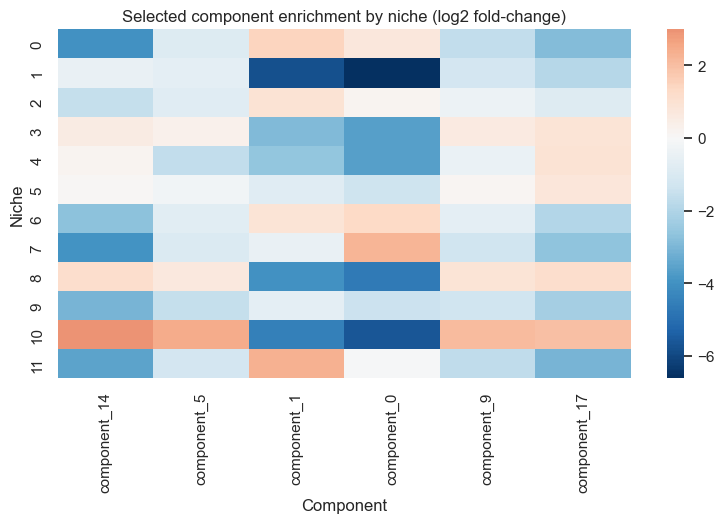

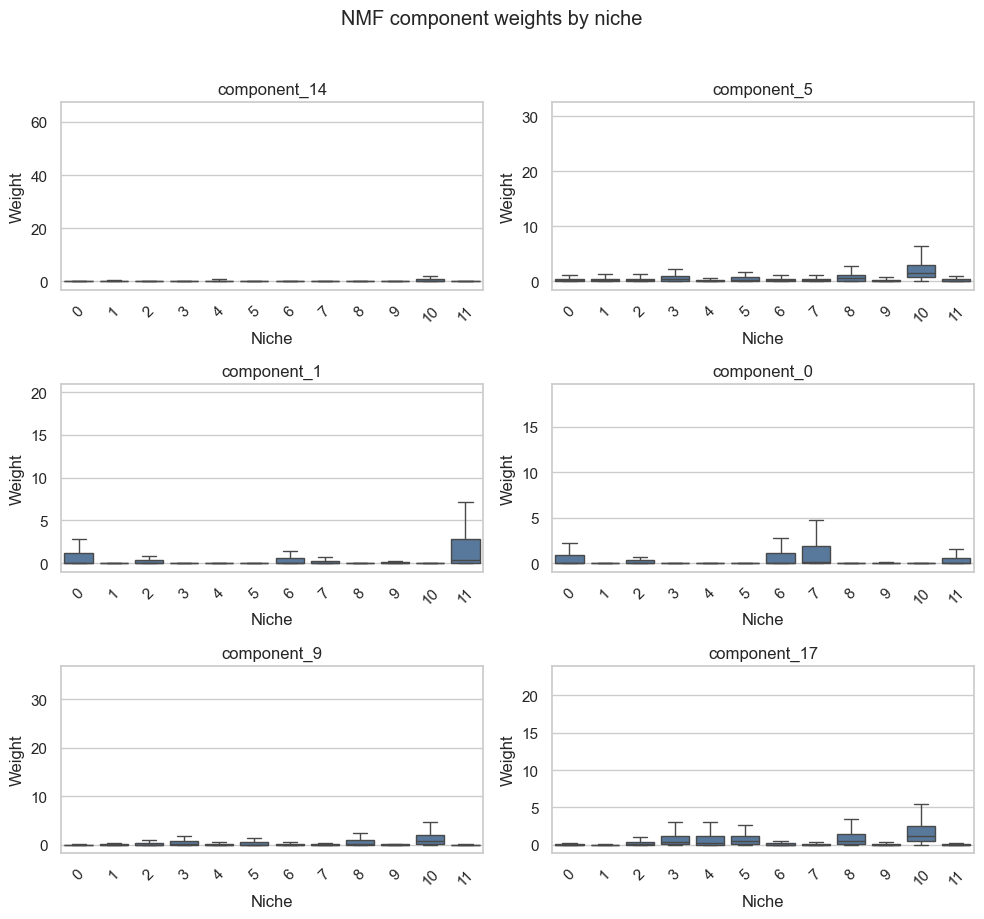

,component_label,gene,loading
0,component_14,SERPINA3,2.699277
1,component_14,VIM,1.829984
2,component_14,GFAP,1.526260
3,component_14,AQP4,1.490264
4,component_14,APOE,0.958080
5,component_14,S100B,0.778755
6,component_14,DKK3,0.741149
7,component_14,GJA1,0.508325
8,component_14,GPRC5B,0.491012
9,component_14,NTRK2,0.484276


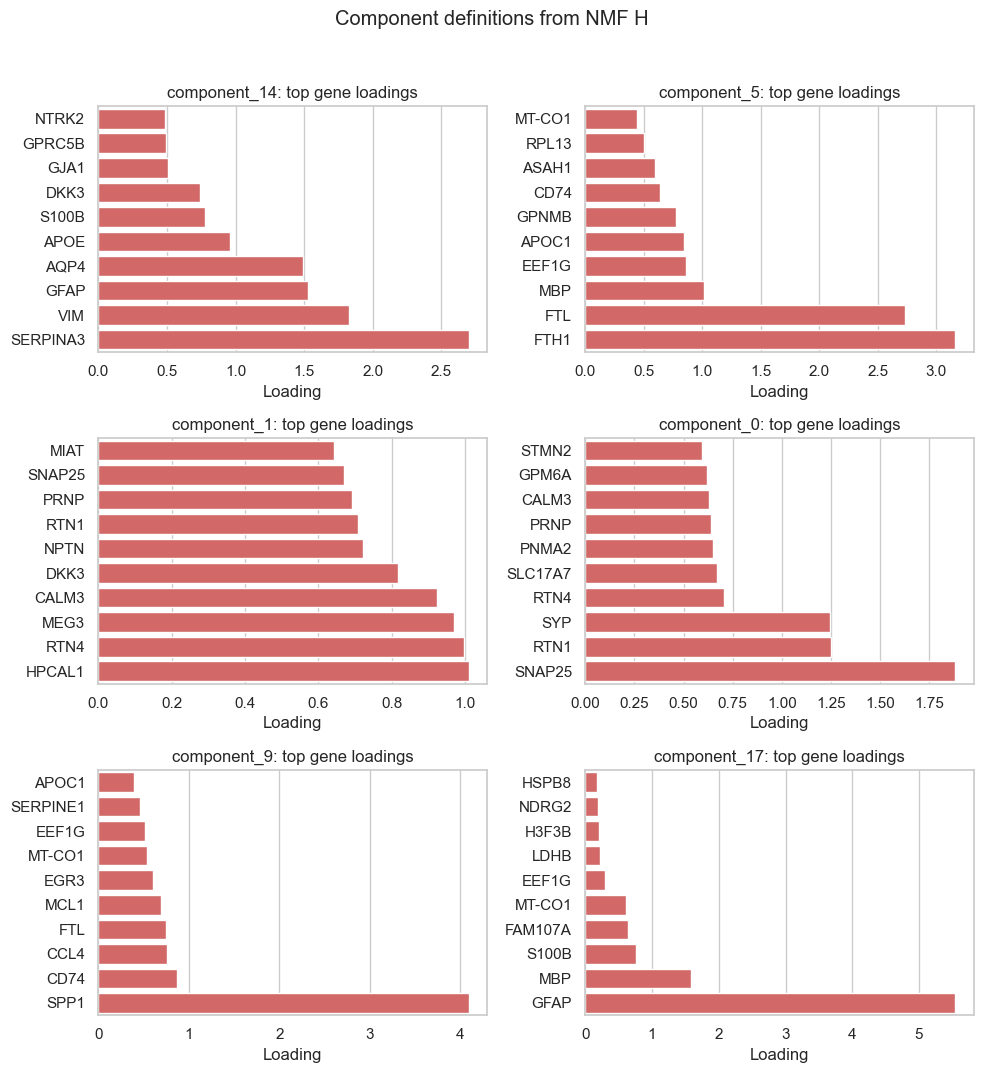

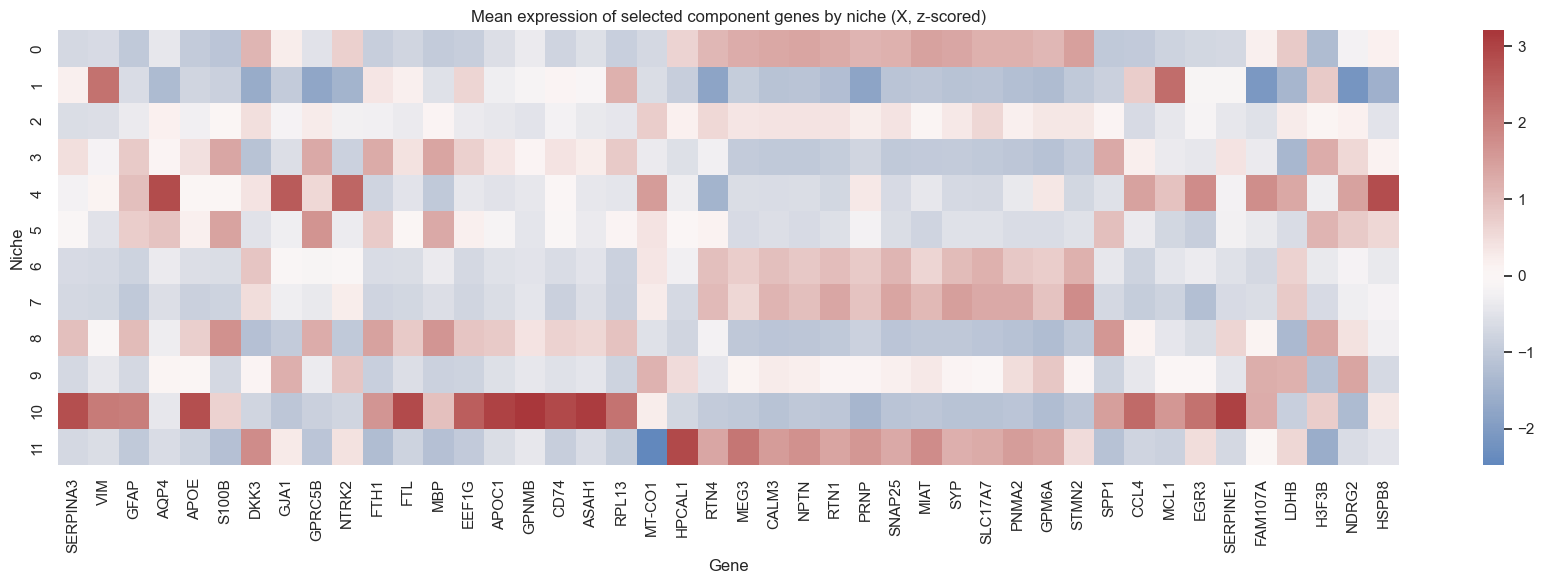

In [46]:
nmf_enrichment = adata.uns.get(f"{OUTPUT_PREFIX}_nmf_component_enrichment")

if isinstance(nmf_enrichment, pd.DataFrame) and not nmf_enrichment.empty and niche_col in adata.obs:
    if NMF_COMPONENT_IDS is None:
        components_to_plot = (
            nmf_enrichment
            .groupby("component", observed=True)["log2fc"]
            .max()
            .sort_values(ascending=False)
            .head(NMF_COMPONENT_PLOTS_MAX)
            .index
            .astype(str)
            .tolist()
        )
    else:
        components_to_plot = [str(c) for c in NMF_COMPONENT_IDS]

    nmf_key = f"{OUTPUT_PREFIX}_nmf_w"
    nmf_cols_key = f"{OUTPUT_PREFIX}_nmf_w_columns"
    nmf_w = adata.obsm.get(nmf_key)
    nmf_cols = adata.uns.get(nmf_cols_key)

    if nmf_w is not None:
        if sparse.issparse(nmf_w):
            nmf_w = nmf_w.toarray()
        nmf_w = np.asarray(nmf_w, dtype=float)
        if not isinstance(nmf_cols, (list, tuple, np.ndarray)) or len(nmf_cols) != nmf_w.shape[1]:
            nmf_cols = [f"component_{i}" for i in range(nmf_w.shape[1])]
        else:
            nmf_cols = [str(c) for c in nmf_cols]

        components_to_plot = [c for c in components_to_plot if c in nmf_cols]
        if components_to_plot:
            niche_ids = adata.obs[niche_col].astype("Int64")
            valid = niche_ids.notna()
            nmf_df = pd.DataFrame(nmf_w, index=adata.obs_names, columns=nmf_cols)
            weight_df = nmf_df.loc[valid, components_to_plot].copy()
            weight_df["niche"] = niche_ids.loc[valid].astype(int).values

            # 1) Heatmap: enrichment (log2FC) of selected components by niche.
            enrich_heat = (
                nmf_enrichment[nmf_enrichment["component"].isin(components_to_plot)]
                .pivot_table(index="niche", columns="component", values="log2fc", aggfunc="first", fill_value=0.0)
                .sort_index()
                .reindex(columns=components_to_plot)
            )
            display(enrich_heat)
            plt.figure(figsize=(max(8, enrich_heat.shape[1] * 0.7), max(4, enrich_heat.shape[0] * 0.45)))
            sns.heatmap(enrich_heat, cmap="RdBu_r", center=0)
            plt.title("Selected component enrichment by niche (log2 fold-change)")
            plt.xlabel("Component")
            plt.ylabel("Niche")
            plt.tight_layout()
            plt.show()

            # 2) Boxplots: component weights per niche.
            long_weights = weight_df.melt(id_vars="niche", var_name="component", value_name="weight")
            n_comp = len(components_to_plot)
            n_cols_plot = 2
            n_rows_plot = int(np.ceil(n_comp / n_cols_plot))
            fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(max(10, 6), max(4, n_rows_plot * 3)), squeeze=False)
            for idx, component in enumerate(components_to_plot):
                r, c = divmod(idx, n_cols_plot)
                ax = axes[r][c]
                tmp = long_weights[long_weights["component"] == component]
                sns.boxplot(data=tmp, x="niche", y="weight", ax=ax, color="#4C78A8", fliersize=0)
                ax.set_title(component)
                ax.set_xlabel("Niche")
                ax.set_ylabel("Weight")
                ax.tick_params(axis="x", rotation=45)
            for idx in range(n_comp, n_rows_plot * n_cols_plot):
                r, c = divmod(idx, n_cols_plot)
                axes[r][c].axis("off")
            fig.suptitle("NMF component weights by niche", y=1.02)
            plt.tight_layout()
            plt.show()

            # 3) Top genes from H for selected components.
            if outputs["nmf_h"] is not None and not outputs["nmf_h"].empty:
                nmf_h = outputs["nmf_h"].copy()
                if {"component", "gene", "loading"}.issubset(nmf_h.columns):
                    nmf_h["component_label"] = nmf_h["component"].astype(int).map(lambda x: f"component_{x}")
                    load_rows = []
                    for component in components_to_plot:
                        top = (
                            nmf_h[nmf_h["component_label"] == component]
                            .sort_values("loading", ascending=False)
                            .head(NMF_TOP_LOADINGS_TO_PLOT)
                            .copy()
                        )
                        load_rows.append(top)
                    top_loadings = pd.concat(load_rows, ignore_index=True) if load_rows else pd.DataFrame()

                    if not top_loadings.empty:
                        display(top_loadings[["component_label", "gene", "loading"]])

                        n_comp = len(components_to_plot)
                        n_cols_plot = 2
                        n_rows_plot = int(np.ceil(n_comp / n_cols_plot))
                        fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(max(10, 6), max(4, n_rows_plot * 3.5)), squeeze=False)
                        for idx, component in enumerate(components_to_plot):
                            r, c = divmod(idx, n_cols_plot)
                            ax = axes[r][c]
                            tmp = top_loadings[top_loadings["component_label"] == component].sort_values("loading", ascending=True)
                            if tmp.empty:
                                ax.axis("off")
                                continue
                            sns.barplot(data=tmp, x="loading", y="gene", ax=ax, color="#E45756")
                            ax.set_title(f"{component}: top gene loadings")
                            ax.set_xlabel("Loading")
                            ax.set_ylabel("")
                        for idx in range(n_comp, n_rows_plot * n_cols_plot):
                            r, c = divmod(idx, n_cols_plot)
                            axes[r][c].axis("off")
                        fig.suptitle("Component definitions from NMF H", y=1.02)
                        plt.tight_layout()
                        plt.show()

                        # 4) Niche-level mean expression of all plotted top genes.
                        top_genes = top_loadings["gene"].dropna().astype(str).drop_duplicates().tolist()
                        expr = get_expression_frame(adata, top_genes, layer=MARKER_LAYER)
                        if not expr.empty:
                            niche_means = expr.loc[valid].groupby(niche_ids.loc[valid].astype(int)).mean().sort_index()
                            scaled = niche_means.copy()
                            for col in scaled.columns:
                                std = scaled[col].std(ddof=0)
                                scaled[col] = 0.0 if std == 0 else (scaled[col] - scaled[col].mean()) / std
                            plt.figure(figsize=(max(10, scaled.shape[1] * 0.4), max(4, scaled.shape[0] * 0.5)))
                            sns.heatmap(scaled, cmap="vlag", center=0)
                            layer_label = MARKER_LAYER if MARKER_LAYER else "X"
                            plt.title(f"Mean expression of selected component genes by niche ({layer_label}, z-scored)")
                            plt.xlabel("Gene")
                            plt.ylabel("Niche")
                            plt.tight_layout()
                            plt.show()
        else:
            print("No selected components overlap nmf_w columns")
else:
    print("NMF enrichment table missing; run the previous enrichment cell first")



### Spatial maps of NMF component scores

Plot per-cell NMF scores directly in tissue space to see where each component is active.


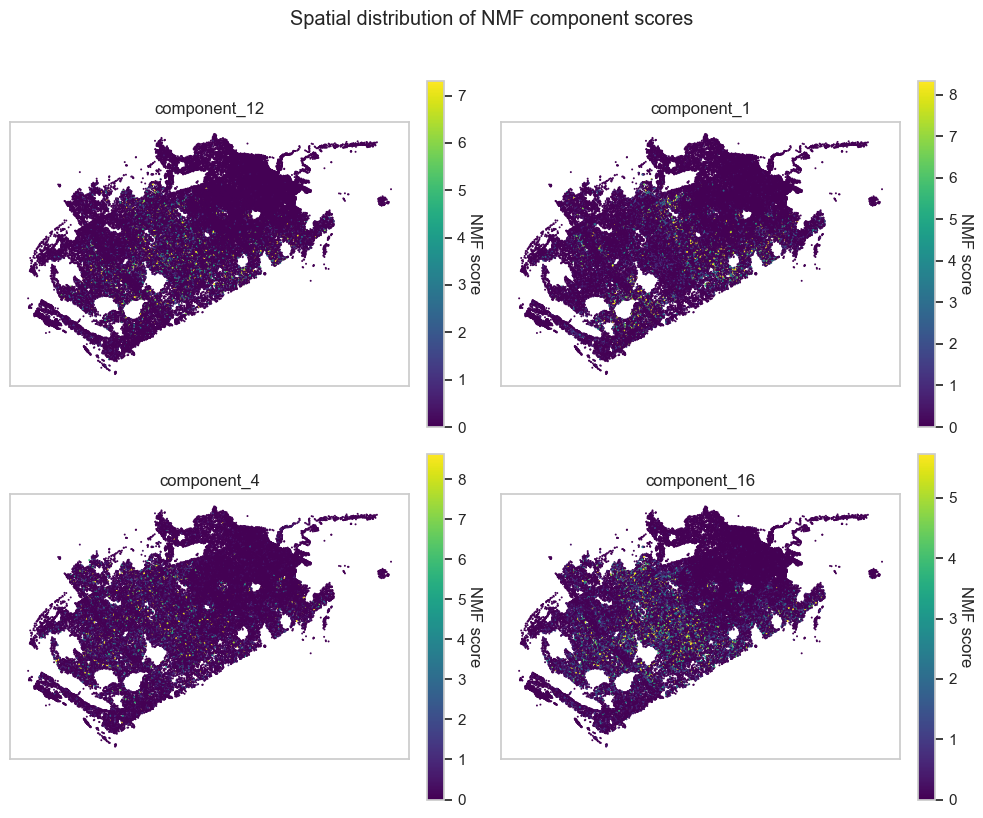

In [47]:
nmf_key = f"{OUTPUT_PREFIX}_nmf_w"
nmf_cols_key = f"{OUTPUT_PREFIX}_nmf_w_columns"

if nmf_key in adata.obsm:
    nmf_w = adata.obsm[nmf_key]
    if sparse.issparse(nmf_w):
        nmf_w = nmf_w.toarray()
    nmf_w = np.asarray(nmf_w, dtype=float)

    nmf_cols = adata.uns.get(nmf_cols_key)
    if not isinstance(nmf_cols, (list, tuple, np.ndarray)) or len(nmf_cols) != nmf_w.shape[1]:
        nmf_cols = [f"component_{i}" for i in range(nmf_w.shape[1])]
    else:
        nmf_cols = [str(c) for c in nmf_cols]

    nmf_df = pd.DataFrame(nmf_w, index=adata.obs_names, columns=nmf_cols)

    if "spatial" in adata.obsm and np.asarray(adata.obsm["spatial"]).shape[1] >= 2:
        coords = pd.DataFrame(np.asarray(adata.obsm["spatial"])[:, :2], index=adata.obs_names, columns=["x", "y"])
    elif {"x_centroid", "y_centroid"}.issubset(adata.obs.columns):
        coords = adata.obs[["x_centroid", "y_centroid"]].copy()
        coords.columns = ["x", "y"]
    else:
        coords = None

    if coords is None:
        print("No spatial coordinates found (need adata.obsm['spatial'] or obs x_centroid/y_centroid)")
    else:
        if NMF_SPATIAL_COMPONENTS is None:
            top_components = adata.uns.get(f"{OUTPUT_PREFIX}_nmf_top_components")
            if isinstance(top_components, pd.DataFrame) and not top_components.empty:
                components_to_plot = top_components["component"].astype(str).drop_duplicates().head(NMF_SPATIAL_N_TOP).tolist()
            else:
                components_to_plot = nmf_cols[:NMF_SPATIAL_N_TOP]
        else:
            components_to_plot = [str(c) for c in NMF_SPATIAL_COMPONENTS]

        components_to_plot = [c for c in components_to_plot if c in nmf_df.columns]

        group_series = None
        if outputs["niches"] is not None and "group" in outputs["niches"].columns:
            group_series = (
                outputs["niches"]
                .drop_duplicates(subset=["cell_i"])
                .set_index("cell_i")["group"]
                .reindex(adata.obs_names)
                .astype("string")
            )
        elif "sample_id" in adata.obs.columns:
            group_series = adata.obs["sample_id"].astype("string")

        mask = pd.Series(True, index=adata.obs_names)
        if NMF_SPATIAL_SAMPLE is not None and group_series is not None:
            mask = group_series.fillna("missing").astype(str).eq(str(NMF_SPATIAL_SAMPLE))

        coords_plot = coords.loc[mask]
        nmf_plot = nmf_df.loc[mask, components_to_plot]

        if coords_plot.empty or not components_to_plot:
            print("No cells/components available for spatial NMF plotting after filtering")
        else:
            n = len(components_to_plot)
            n_cols_plot = 2
            n_rows_plot = int(np.ceil(n / n_cols_plot))
            fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(max(10, 6), max(4, n_rows_plot * 4)), squeeze=False)

            for idx, component in enumerate(components_to_plot):
                r, c = divmod(idx, n_cols_plot)
                ax = axes[r][c]
                vals = nmf_plot[component].to_numpy()
                vmin = np.nanquantile(vals, NMF_SPATIAL_QMIN)
                vmax = np.nanquantile(vals, NMF_SPATIAL_QMAX)
                if not np.isfinite(vmin):
                    vmin = None
                if not np.isfinite(vmax):
                    vmax = None
                sc = ax.scatter(
                    coords_plot["x"],
                    coords_plot["y"],
                    c=vals,
                    s=NMF_SPATIAL_POINT_SIZE,
                    cmap=NMF_SPATIAL_CMAP,
                    vmin=vmin,
                    vmax=vmax,
                    linewidths=0,
                    rasterized=True,
                )
                ax.set_title(component)
                ax.set_aspect("equal", adjustable="box")
                ax.invert_yaxis()
                ax.set_xticks([])
                ax.set_yticks([])
                cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
                cbar.set_label("NMF score", rotation=270, labelpad=12)

            for idx in range(n, n_rows_plot * n_cols_plot):
                r, c = divmod(idx, n_cols_plot)
                axes[r][c].axis("off")

            sample_label = f" | sample={NMF_SPATIAL_SAMPLE}" if NMF_SPATIAL_SAMPLE is not None else ""
            fig.suptitle(f"Spatial distribution of NMF component scores{sample_label}", y=1.02)
            plt.tight_layout()
            plt.show()
else:
    print(f"Missing {nmf_key} in adata.obsm")



morans_nmf


,feature,moran_i,expected_i,variance_i,z_score,group
25,component_5,0.551523,-0.000025,1.542720e-07,1404.233796,Balo-2
37,component_17,0.294900,-0.000025,1.542720e-07,750.874015,Balo-2
29,component_9,0.179091,-0.000025,1.542720e-07,456.025507,Balo-2
23,component_3,0.157331,-0.000025,1.542720e-07,400.626344,Balo-2
3,component_3,0.206794,-0.000032,3.237057e-07,363.522344,Balo-1
17,component_17,0.163477,-0.000032,3.237057e-07,287.387634,Balo-1
0,component_0,0.139757,-0.000032,3.237057e-07,245.696527,Balo-1
34,component_14,0.094083,-0.000025,1.542720e-07,239.596359,Balo-2
36,component_16,0.092922,-0.000025,1.542720e-07,236.640318,Balo-2
1,component_1,0.128789,-0.000032,3.237057e-07,226.418370,Balo-1


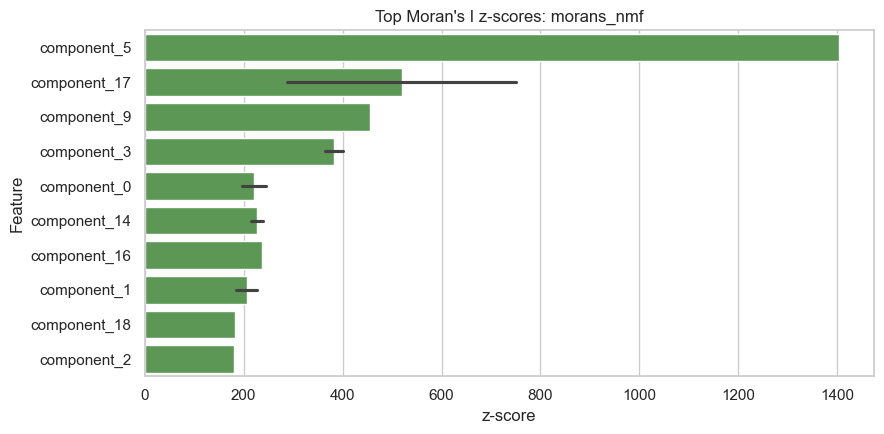

morans_embedding


,feature,moran_i,expected_i,variance_i,z_score,group
13,dim_3,0.507887,-0.000025,1.542720e-07,1293.138046,Balo-2
10,dim_0,0.360657,-0.000025,1.542720e-07,918.292257,Balo-2
19,dim_9,0.240858,-0.000025,1.542720e-07,613.284742,Balo-2
14,dim_4,0.148230,-0.000025,1.542720e-07,377.453780,Balo-2
15,dim_5,0.110881,-0.000025,1.542720e-07,282.363564,Balo-2
9,dim_9,0.159573,-0.000032,3.237057e-07,280.525568,Balo-1
17,dim_7,0.108405,-0.000025,1.542720e-07,276.059163,Balo-2
3,dim_3,0.151613,-0.000032,3.237057e-07,266.535047,Balo-1
2,dim_2,0.151163,-0.000032,3.237057e-07,265.744606,Balo-1
6,dim_6,0.118882,-0.000032,3.237057e-07,209.005516,Balo-1


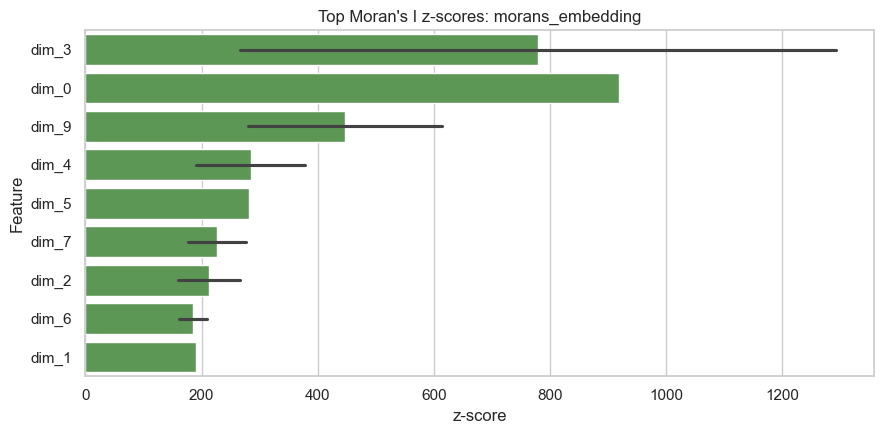

,group,cell_type_a,cell_type_b,observed,expected_mean,expected_std,z_score,p_value
72,Balo-1,13,13,47535,5533.154,114.394398,367.166983,0.000999
141,Balo-2,2,2,893243,166415.601,2695.461238,269.648619,0.000999
202,Balo-2,10,2,466758,133262.035,1913.080939,174.324023,0.000999
37,Balo-1,1,11,10221,2063.356,60.962310,133.814548,0.000999
188,Balo-2,11,2,376503,140473.908,1900.951431,124.163663,0.000999
8,Balo-1,10,10,10168,2293.768,63.583128,123.841532,0.000999
101,Balo-1,1,1,17436,5723.623,114.822693,102.004026,0.000999
30,Balo-1,11,11,1759,184.965,15.459035,101.819742,0.000999
42,Balo-1,1,9,17405,6264.829,114.900199,96.955193,0.000999
39,Balo-1,11,2,1885,249.558,17.658670,92.614108,0.000999


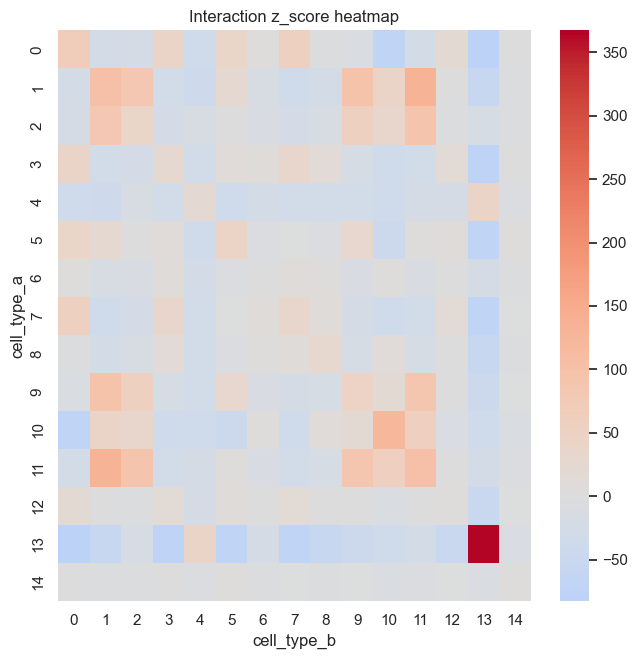

In [48]:
for label in ["morans_nmf", "morans_embedding"]:
    morans = adata.uns.get(f"{OUTPUT_PREFIX}_{label}")
    if isinstance(morans, pd.DataFrame) and not morans.empty:
        print(label)
        top_morans = morans.sort_values("z_score", ascending=False).head(15)
        display(top_morans)
        plt.figure(figsize=(9, max(4, len(top_morans) * 0.3)))
        sns.barplot(data=top_morans, x="z_score", y="feature", color="#54A24B")
        plt.title(f"Top Moran's I z-scores: {label}")
        plt.xlabel("z-score")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.show()

interaction_stats = adata.uns.get(f"{OUTPUT_PREFIX}_interaction_stats")
if isinstance(interaction_stats, pd.DataFrame) and not interaction_stats.empty:
    score_col = "z_score" if "z_score" in interaction_stats.columns else "count"
    top_interactions = interaction_stats.reindex(
        interaction_stats[score_col].abs().sort_values(ascending=False).index
    ).head(20)
    display(top_interactions)

    heat = interaction_stats.pivot_table(
        index="cell_type_a",
        columns="cell_type_b",
        values=score_col,
        aggfunc="first",
    )
    heat = heat.combine_first(heat.T)
    plt.figure(figsize=(max(6, heat.shape[1] * 0.45), max(5, heat.shape[0] * 0.45)))
    sns.heatmap(heat, cmap="coolwarm", center=0 if score_col == "z_score" else None)
    plt.title(f"Interaction {score_col} heatmap")
    plt.xlabel("cell_type_b")
    plt.ylabel("cell_type_a")
    plt.tight_layout()
    plt.show()
else:
    print("No interaction_stats table available")


## Optional: write a new `.h5ad`

Set `SAVE_H5AD_PATH = None` in the config cell if you only want the in-memory object.


In [49]:
if SAVE_H5AD_PATH is not None:
    SAVE_H5AD_PATH.parent.mkdir(parents=True, exist_ok=True)
    adata.write(SAVE_H5AD_PATH)
    print(f"wrote {SAVE_H5AD_PATH}")
else:
    print("skipping write; SAVE_H5AD_PATH is None")


wrote ../projects/balo-take2/mapped_outputs.h5ad


In [50]:
import sys
sys.path.append("/Users/christoffer/work/karolinska/development/MANA")
from utils import aggregate_neighbors_weighted, plot_spatial_compact_fast

In [51]:
adata

AnnData object with n_obs × n_vars = 71721 × 5101
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'sample_id', 'n_genes_by_counts', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_1.5', 'leiden_2', 'gmm_mana_5', 'gmm_mana_8', 'gmm_mana_10', 'gmm_mana_12', 'gmm_mana_15', 'gmm_mana_20', 'spatialrs_niche', 'spatialrs_niche_confidence', 'spatialrs_niche_entropy'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'X_mana_gauss_params', 'gmm_mana_10_colors', 'gmm_mana_15_colors', 'gmm_mana_20_colors', 'gmm_mana_5_colors', 'gmm_mana_8_colors', 'hvg', 'leiden_0.5', 'leiden_0.5_colors', 'leiden_1', 'leiden_1.5', 'leiden_1.5_col

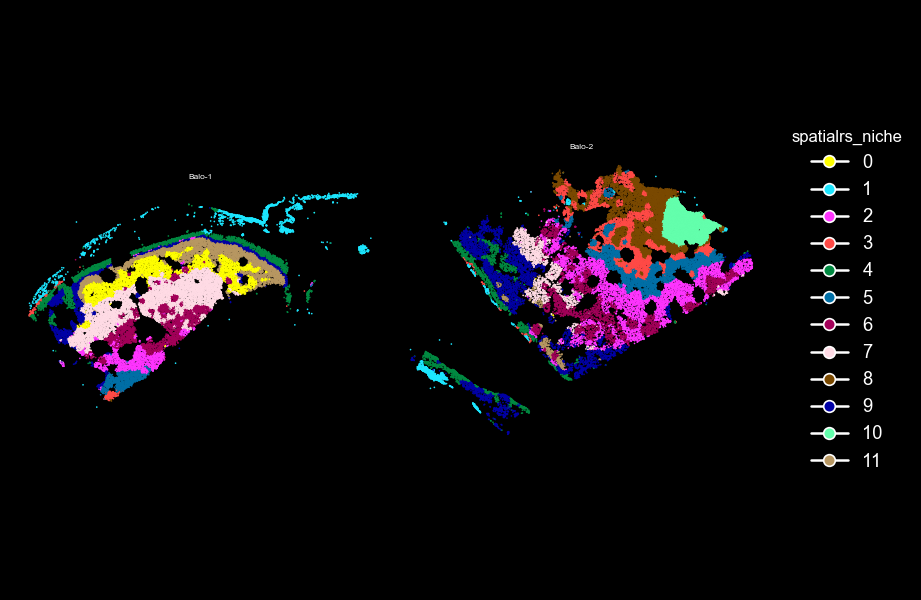

In [52]:
plot_spatial_compact_fast(
    adata,
    color="spatialrs_niche",
    groupby="sample_id",
    spot_size=1,
    cols=2,
    height=5,
    background="black",
    dpi=120,
)


### Plot NMF components with `plot_spatial_compact_fast`

Map selected NMF component scores into `adata.obs` and render each one with your compact spatial plotting utility.


In [65]:
NMF_OBS_COMPONENTS = ['component_14'] 

Mapped NMF score columns into adata.obs:
['spatialrs_nmf_score_component_14']


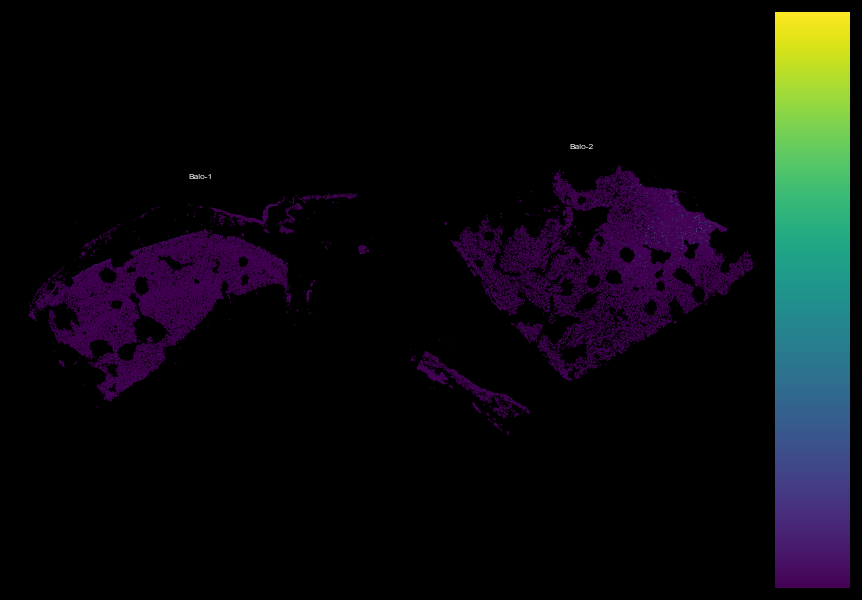

In [66]:
nmf_obs_cols = map_nmf_components_to_obs(
    adata,
    output_prefix=OUTPUT_PREFIX,
    components=NMF_OBS_COMPONENTS,
    top_n=NMF_OBS_TOP_N,
    obs_prefix=NMF_OBS_PREFIX,
)

print("Mapped NMF score columns into adata.obs:")
print(nmf_obs_cols)

if len(nmf_obs_cols) == 0:
    print("No NMF components were mapped; check NMF_OBS_COMPONENTS and available columns")
else:
    for color_col in nmf_obs_cols:
        plot_spatial_compact_fast(
            adata,
            
            color=color_col,
            groupby=NMF_OBS_PLOT_GROUPBY,
            spot_size=0.5,
            cols=NMF_OBS_PLOT_COLS,
            height=NMF_OBS_PLOT_HEIGHT,
            background=NMF_OBS_PLOT_BACKGROUND,
            dpi=NMF_OBS_PLOT_DPI,
            
        )

